In [6]:
import pandas as pd
from collections import defaultdict
import numpy as np

def load_sentiwordnet(path):
    scores = defaultdict(list)

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith("#"):
                continue

            parts = line.strip().split('\t')
            if len(parts) != 6:
                continue

            pos, synset_id, pos_score, neg_score, terms, gloss = parts
            pos_score = float(pos_score)
            neg_score = float(neg_score)

            words = terms.split()

            for w in words:
                word = w.split('#')[0]
                scores[word].append((pos_score, neg_score))


    # average scores per word
    word_scores = {}
    for word, vals in scores.items():
        pos_avg = sum(v[0] for v in vals) / len(vals)
        neg_avg = sum(v[1] for v in vals) / len(vals)
        word_scores[word] = (pos_avg, neg_avg)

    return word_scores


swn = load_sentiwordnet("SentiWordNet_3.0.0.txt")

print(swn["cheap"])
print(swn["good"])
print(swn["bad"])

(0.0625, 0.4375)
(0.5694444444444444, 0.004629629629629629)
(0.029411764705882353, 0.625)


In [7]:
def rank_words_by_connotation(swn_scores):
    """
    Build a sorted list of words with positive, negative, and total connotation score.

    total_connotation = positive_score + negative_score
    """
    ranked = []

    for word, (pos_score, neg_score) in swn_scores.items():
        #total_score = pos_score + neg_score
        total_score = pos_score*neg_score
        ranked.append((word, pos_score, neg_score, total_score))
        

    ranked.sort(key=lambda x: x[3], reverse=True)
    return ranked


ranked_words = rank_words_by_connotation(swn)

def print_top_words(ranked_words, top_k=10):
    print("Top 10 words by total connotation score:")
    for word, pos_score, neg_score, total_score in ranked_words[:top_k]:
        print(f"{word:20s} pos={pos_score:.3f} neg={neg_score:.3f} total={total_score:.3f}")
  

print(swn["cheap"])

(0.0625, 0.4375)


In [8]:

def store_word_list(word_list, filename):
    #first recover wordd already in the file if it exists
    try:        
        with open(filename, 'r', encoding='utf-8') as f:
            existing_words = set(line.strip() for line in f)
    except FileNotFoundError:
        existing_words = set()
    #combine existing words with new ones, avoiding duplicates
    combined_words = existing_words.union(set(word_list))
    with open(filename, 'w', encoding='utf-8') as f:
        for word in combined_words:
            f.write(word + '\n')

word_list = [w[0] for w in ranked_words[:20]]
store_word_list(word_list, "top_connotation_words.txt")

In [9]:
from collections import Counter
import re

from datasets import load_dataset

# Load only SST2 train split from Hugging Face Datasets
#sst = load_dataset("sst2", split="train")
sst = load_dataset("sst2", split="train", download_mode="force_redownload")

word_counts = Counter()

if "sentence" in sst.column_names:
    sentence_field = "sentence"
elif "text" in sst.column_names:
    sentence_field = "text"
else:
    raise ValueError("No sentence/text field found in SST2 train split.")

for sentence in sst[sentence_field]:
    words = re.findall(r"[a-z']+", sentence.lower())
    word_counts.update(words)

# Sorted list of (word, count) from most frequent to least frequent
sorted_words_by_occurrence = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

Extracting data files: 100%|██████████| 3/3 [00:00<00:00, 107.93it/s]


Dataset parquet downloaded and prepared to C:/Users/ayoub/.cache/huggingface/datasets/parquet/sst2-c614fb49d6bf6d65/0.0.0/2a3b91fbd88a2c90d1dbbb32b460cf621d31bd5b05b934492fdef7d8d6f236ec. Subsequent calls will reuse this data.


In [10]:
#print the number of words that have more than 100 occurrences
num_words_over_100 = sum(1 for word, count in sorted_words_by_occurrence if count > 100)
print(f"Number of words with more than 100 occurrences: {num_words_over_100}")

#extract the words in swn that have more than 100 occurrences in SST
frequent_words_in_sst = [word for word, count in sorted_words_by_occurrence if count > 200 and word in swn]
# rank the frequent words in sst by their total connotation score in swn
frequent_words_in_sst_ranked = sorted(frequent_words_in_sst, key=lambda w: swn[w][0]*swn[w][1], reverse=True)

word_base = [word for word in frequent_words_in_sst_ranked[:50]]

print("Top frequent words in SST ranked by connotation score:")
for word in word_base:
    pos_score, neg_score = swn[word]
    total_score = pos_score*neg_score
    print(f"{word:20s} pos={pos_score:.3f} neg={neg_score:.3f} total={total_score:.3f}")
    

Number of words with more than 100 occurrences: 702
Top frequent words in SST ranked by connotation score:
might                pos=0.375 neg=0.500 total=0.188
entertaining         pos=0.625 neg=0.250 total=0.156
pretty               pos=0.333 neg=0.417 total=0.139
enjoyable            pos=0.500 neg=0.250 total=0.125
quite                pos=0.312 neg=0.312 total=0.098
smart                pos=0.306 neg=0.222 total=0.068
worst                pos=0.083 neg=0.688 total=0.057
charming             pos=0.438 neg=0.125 total=0.055
emotional            pos=0.406 neg=0.125 total=0.051
rather               pos=0.156 neg=0.281 total=0.044
fresh                pos=0.144 neg=0.250 total=0.036
very                 pos=0.375 neg=0.094 total=0.035
funny                pos=0.125 neg=0.275 total=0.034
strong               pos=0.225 neg=0.150 total=0.034
simply               pos=0.344 neg=0.094 total=0.032
compelling           pos=0.250 neg=0.125 total=0.031
other                pos=0.094 neg=0.312 tota

In [11]:
# Build a dataset with columns: sentence | word | label
# Keep only words that are present in word_base.
word_base_set = set(word_base)
rows = []

if "sentence" in sst.column_names:
    sentence_field = "sentence"
elif "text" in sst.column_names:
    sentence_field = "text"
else:
    raise ValueError("No sentence/text field found in SST2 train split.")

has_label = "label" in sst.column_names

for example in sst:
    sentence = example[sentence_field]
    label = example["label"] if has_label else None

    words = re.findall(r"[a-z']+", sentence.lower())
    for word in words:
        if word in word_base_set:
            rows.append(
                {
                    "sentence": sentence,
                    "word": word,
                    "label": label,
                }
            )

sst2_sentence_word_label = pd.DataFrame(rows, columns=["sentence", "word", "label"])

print(f"Constructed rows: {len(sst2_sentence_word_label)}")
sst2_sentence_word_label.head(10)

Constructed rows: 23949


,sentence,word,label
0,hide new secretions from the parental units,new,0
1,"contains no wit , only labored gags",no,0
2,that loves its characters and communicates som...,rather,1
3,on the worst revenge-of-the-nerds clichés the ...,worst,0
4,demonstrates that the director of such hollywo...,still,1
5,demonstrates that the director of such hollywo...,emotional,1
6,a depressed fifteen-year-old 's suicidal poetry,old,0
7,"the part where nothing 's happening ,",nothing,0
8,saw how bad this movie was,bad,0
9,lend some dignity to a dumb story,some,0


In [12]:
example_word = "rather"

examples = sst2_sentence_word_label[sst2_sentence_word_label["word"] == example_word]

for idx, row in examples.iterrows():
    print(f"Sentence: {row['sentence']}")
    print(f"Label: {row['label']}")
    print()
    

Sentence: that loves its characters and communicates something rather beautiful about human nature 
Label: 1

Sentence: with color and depth , and rather a good time 
Label: 1

Sentence: rather choppy 
Label: 0

Sentence: ... familiar and predictable , and 4/5ths of it might as well have come from a xerox machine rather than ( writer-director ) franc . 
Label: 0

Sentence: famuyiwa 's feature deals with its subject matter in a tasteful , intelligent manner , rather than forcing us to endure every plot contrivance that the cliché-riddled genre can offer . 
Label: 1

Sentence: a watch that makes time go faster rather than 
Label: 1

Sentence: like one long , meandering sketch inspired by the works of john waters and todd solondz , rather than a fully developed story 
Label: 0

Sentence: a rather simplistic one : grief drives her , love drives him , and a second chance to find love in the most unlikely place 
Label: 1

Sentence: a laughable -- or rather 
Label: 0

Sentence: essentially ru

## Contextual Embedding Analysis (Repository Pipeline)

This section computes contextual embeddings for `(sentence, word, label)` rows from `sst2_sentence_word_label` using the same repository embedding stack (`Config` + `make_predictor_for_train_reader`) and then measures how strongly embeddings separate positive vs negative sentiment for each target word.

In [13]:
import os
import re
import sys
import numpy as np
import pandas as pd
import tqdm

# Ensure repository root is importable when notebook cwd is MVA/
if os.path.basename(os.getcwd()).lower() == "mva":
    repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
else:
    repo_root = os.getcwd()

if repo_root not in sys.path:
    sys.path.append(repo_root)

from bssp.common.config import Config
from bssp.common.reading import make_predictor_for_train_reader

# -------- parameters --------
EMBEDDING_MODEL = "bert-base-cased"
BERT_LAYERS = [7]
ANALYSIS_MAX_ROWS = 3000  # set to None to run on all rows
RANDOM_SEED = 13

# Build input rows from previously constructed dataframe
analysis_df = sst2_sentence_word_label.copy()
analysis_df = analysis_df.dropna(subset=["sentence", "word"]).reset_index(drop=True)
analysis_df["word"] = analysis_df["word"].astype(str).str.lower()

# Distinguish repeated occurrences of the same word in the same sentence
group_cols = ["sentence", "word"]
if "label" in analysis_df.columns:
    group_cols.append("label")
analysis_df["occurrence_rank"] = analysis_df.groupby(group_cols).cumcount()

if ANALYSIS_MAX_ROWS is not None and len(analysis_df) > ANALYSIS_MAX_ROWS:
    analysis_df = analysis_df.sample(ANALYSIS_MAX_ROWS, random_state=RANDOM_SEED).reset_index(drop=True)

cfg = Config(
    corpus_name="custom",
    embedding_model=EMBEDDING_MODEL,
    bert_layers=BERT_LAYERS,
    metric="cosine",
    top_n=50,
    query_n=1,
    override_weights_path=None,
)
predictor = make_predictor_for_train_reader(cfg)

def _tokenize(sentence: str):
    # Keep a simple word-level tokenization compatible with row construction
    return re.findall(r"[A-Za-z']+", sentence)

embedded_rows = []
skipped = 0

for _, row in tqdm.tqdm(analysis_df.iterrows(), total=len(analysis_df), desc="Embedding target words"):
    sentence = row["sentence"]
    target_word = row["word"]
    occurrence_rank = int(row["occurrence_rank"])

    tokens = _tokenize(sentence)
    if not tokens:
        skipped += 1
        continue

    lower_tokens = [t.lower() for t in tokens]
    positions = [i for i, tok in enumerate(lower_tokens) if tok == target_word]
    if occurrence_rank >= len(positions):
        skipped += 1
        continue
    target_idx = positions[occurrence_rank]

    pred = predictor.predict(tokens)
    embs = np.asarray(pred["embeddings"], dtype=np.float32)
    if target_idx >= len(embs):
        skipped += 1
        continue

    embedded_rows.append(
        {
            "sentence": sentence,
            "word": target_word,
            "label": row["label"] if "label" in row else None,
            "token_index": target_idx,
            "embedding": embs[target_idx],
        }
    )

embedded_df = pd.DataFrame(embedded_rows)
print(f"Embedded rows: {len(embedded_df)} | Skipped rows: {skipped}")
print(f"Embedding dimension: {embedded_df['embedding'].iloc[0].shape[0] if len(embedded_df) else 'N/A'}")
embedded_df.head(5)

c:\Users\ayoub\miniconda3\envs\bhus\lib\site-packages\google\api_core\_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.8.20). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
c:\Users\ayoub\miniconda3\envs\bhus\lib\site-packages\google\auth\__init__.py:52: FutureWarning: You are using a Python version 3.8 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.8"), FutureWarning)
c:\Users\ayoub\miniconda3\envs\bhus\lib\site-packages\google\oauth2\__init__.py:38: FutureWarning: You are using a Python version 3.8 past its end of life. Google will update google-auth with cri

Embedded rows: 2989 | Skipped rows: 11
Embedding dimension: 768


,sentence,word,label,token_index,embedding
0,"familiar and predictable , and 4/5ths of it mi...",well,0,9,"[-0.97079957, 0.040961843, -0.51207006, 0.6347..."
1,undermining the story 's emotional thrust,emotional,1,4,"[1.1299318, 0.35130876, 0.0656747, 1.4824283, ..."
2,compelling and horrifying,compelling,1,0,"[0.3430983, -0.37470263, -0.4689544, 0.1663086..."
3,belongs in the very top rank of french filmmak...,very,1,3,"[0.27756396, 0.4505627, -0.9329052, 0.7880872,..."
4,"the percussion rhythm , the brass soul and the...",fun,1,20,"[-0.018542636, 0.6117156, -0.32215947, -0.3983..."


In [14]:
def _cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    denom = (np.linalg.norm(a) * np.linalg.norm(b))
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)

def _mean_intra_cosine_distance(vectors: np.ndarray, centroid: np.ndarray) -> float:
    if len(vectors) == 0:
        return np.nan
    sims = [_cosine_similarity(v, centroid) for v in vectors]
    return float(np.mean([1.0 - s for s in sims]))

summary_rows = []
MIN_PER_LABEL = 5

for word, group in embedded_df.groupby("word"):
    if "label" not in group.columns:
        continue

    group = group.dropna(subset=["label"])
    if group.empty:
        continue

    labels = sorted(set(group["label"].tolist()))
    if not ({0, 1}.issubset(set(labels))):
        continue

    g0 = group[group["label"] == 0]
    g1 = group[group["label"] == 1]
    if len(g0) < MIN_PER_LABEL or len(g1) < MIN_PER_LABEL:
        continue

    v0 = np.stack(g0["embedding"].to_numpy())
    v1 = np.stack(g1["embedding"].to_numpy())
    c0 = v0.mean(axis=0)
    c1 = v1.mean(axis=0)

    inter_dist = 1.0 - _cosine_similarity(c0, c1)
    intra0 = _mean_intra_cosine_distance(v0, c0)
    intra1 = _mean_intra_cosine_distance(v1, c1)
    margin = inter_dist - ((intra0 + intra1) / 2.0)

    summary_rows.append(
        {
            "word": word,
            "count_label0": len(g0),
            "count_label1": len(g1),
            "inter_centroid_cosine_distance": inter_dist,
            "intra_label0_cosine_distance": intra0,
            "intra_label1_cosine_distance": intra1,
            "separation_margin": margin,
        }
    )

word_separation_df = pd.DataFrame(summary_rows).sort_values(
    by="separation_margin", ascending=False
).reset_index(drop=True)

print(f"Words analyzed with both labels and >= {MIN_PER_LABEL} examples each: {len(word_separation_df)}")
word_separation_df.head(20)

Words analyzed with both labels and >= 5 examples each: 42


,word,count_label0,count_label1,inter_centroid_cosine_distance,intra_label0_cosine_distance,intra_label1_cosine_distance,separation_margin
0,sweet,6,37,0.152796,0.128956,0.139232,0.018702
1,quite,18,28,0.139441,0.202947,0.155416,-0.039741
2,simply,14,7,0.088370,0.118758,0.168846,-0.055432
3,want,18,13,0.099292,0.151640,0.165577,-0.059317
4,compelling,8,40,0.063126,0.114323,0.142179,-0.065125
5,heart,7,40,0.106216,0.164454,0.182316,-0.067169
6,emotional,13,35,0.015045,0.091548,0.088029,-0.074744
7,documentary,11,34,0.041369,0.120986,0.124834,-0.081541
8,dark,7,25,0.039922,0.114617,0.134637,-0.084705
9,enjoy,12,19,0.036105,0.116792,0.140923,-0.092753


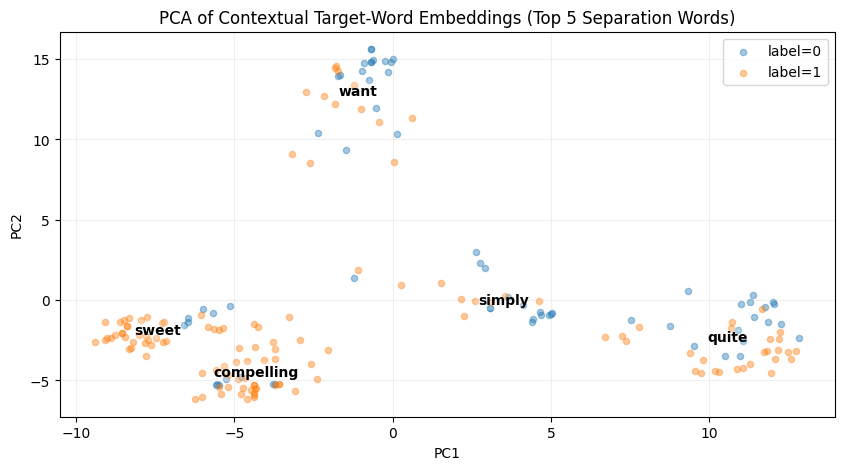

Top words by separation margin:


,word,count_label0,count_label1,inter_centroid_cosine_distance,intra_label0_cosine_distance,intra_label1_cosine_distance,separation_margin
0,sweet,6,37,0.152796,0.128956,0.139232,0.018702
1,quite,18,28,0.139441,0.202947,0.155416,-0.039741
2,simply,14,7,0.088370,0.118758,0.168846,-0.055432
3,want,18,13,0.099292,0.151640,0.165577,-0.059317
4,compelling,8,40,0.063126,0.114323,0.142179,-0.065125


In [19]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

TOP_N_WORDS = 5

if len(word_separation_df) == 0:
    print("No words satisfy the label-balance constraints for plotting.")
else:
    top_words = word_separation_df.head(TOP_N_WORDS)["word"].tolist()
    plot_df = embedded_df[embedded_df["word"].isin(top_words)].dropna(subset=["label"]).copy()

    X = np.stack(plot_df["embedding"].to_numpy())
    pca = PCA(n_components=2, random_state=13)
    X2 = pca.fit_transform(X)
    plot_df["pc1"] = X2[:, 0]
    plot_df["pc2"] = X2[:, 1]

    plt.figure(figsize=(10, 5))

    for label_value in sorted(plot_df["label"].unique()):
        sub = plot_df[plot_df["label"] == label_value]
        plt.scatter(
            sub["pc1"],
            sub["pc2"],
            alpha=0.4,
            s=20,
            label=f"label={label_value}",
        )

    # Annotate each target word at its PCA centroid position
    centroids = plot_df.groupby("word")[["pc1", "pc2"]].mean().reset_index()
    for _, row in centroids.iterrows():
        plt.text(
            row["pc1"],
            row["pc2"],
            row["word"],
            fontsize=10,
            fontweight="bold",
            ha="center",
            va="center",
            bbox={"boxstyle": "round,pad=0.2", "fc": "white", "alpha": 0.2, "ec": "none"},
        )

    plt.title("PCA of Contextual Target-Word Embeddings (Top 5 Separation Words)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    print("Top words by separation margin:")
    display(word_separation_df.head(TOP_N_WORDS))